# Figuras estadísticas del manuscrito (Figures 2, 3, 4)

Este notebook reúne, en un solo lugar, las tres figuras del manuscrito con contenido estadístico
(Figure 2 — AUC por panel ROI y sitio, Figure 3 — forest plot de sensibilidad, Figure 4 — curvas ROC),
para poder **visualizarlas juntas** y **ajustar su estilo** (colores, tipografía, tamaños) sin tener
que editar el `.docx` ni el script de producción directamente.

**No queda incluida Figure 1** (diagrama de redes anatómicas): no tiene contenido estadístico, es una
ilustración de las regiones/redes usadas para definir los paneles ROI.

## Garantías (no negociables)

- Este notebook **no recalcula ni reanaliza** ningún resultado científico. Todos los datos numéricos
  provienen de archivos ya congelados y ya usados en el manuscrito:
  - `analysis/roi_comparison/outputs/data/metrics_by_repeat.csv`
  - `analysis/roi_comparison/outputs/tables/descriptive_performance.csv`
  - `analysis/roi_comparison/outputs/tables/figure4_v6_audit.csv`
  - `results/runs/<roi>/<run_id>/predictions_val.csv` (solo para las curvas ROC; el AUC recomputado
    aquí es una comprobación de QA contra `descriptive_performance.csv`, no un resultado nuevo)
- La lógica de cada figura es la misma ya usada en
  `docs/manuscrito_revisado/figure_style_r2/scripts/build_restyled_figures.py` (script protegido de
  producción); este notebook la reproduce en celdas editables para iterar sobre el estilo más rápido,
  pero **no importa ni modifica** ese script ni los scripts científicos protegidos
  (`run_statistical_analysis.py`, `generate_manuscript_figures_v6.py`).
- **Por defecto, este notebook no sobrescribe ningún archivo.** Todas las figuras se muestran en línea
  (`plt.show()`). Guardar cambios sobre los PNG/SVG oficiales del manuscrito es un paso explícito y
  aislado al final del notebook (celda "Guardar cambios"), apagado por defecto.

## Cómo usar este notebook

1. Ejecutar las celdas de configuración (imports, rutas, estilo).
2. Ejecutar la celda de galería para ver de un vistazo las 3 figuras tal como están hoy en el manuscrito.
3. Para ajustar el estilo: editar la celda **"Estilo compartido"** (colores, fuente, tamaños) y volver a
   ejecutar la figura que se quiera revisar. Los cambios se ven de inmediato, sin guardar nada todavía.
4. Si el equipo decide adoptar un cambio de estilo, usar la celda final "Guardar cambios" para
   sobrescribir los PNG/SVG usados por el manuscrito (`figure_style_r2/figures/`).


In [1]:
# Imports
from __future__ import annotations

from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline


In [2]:
# --- Ruta del repositorio (autodetectada) ---
# Busca hacia arriba, desde el directorio donde se ejecuta el notebook, la carpeta que
# contiene los datos congelados. Si falla la autodetección (por ejemplo, si mueves este
# notebook a otra carpeta), edita REPO_ROOT_OVERRIDE con la ruta absoluta al repositorio.

REPO_ROOT_OVERRIDE = None  # p.ej. Path("/Users/tu_usuario/tdha-revision")

def _find_repo_root() -> Path:
    if REPO_ROOT_OVERRIDE is not None:
        return Path(REPO_ROOT_OVERRIDE)
    marker = Path("analysis") / "roi_comparison" / "outputs" / "data" / "metrics_by_repeat.csv"
    cur = Path.cwd()
    for _ in range(8):
        if (cur / marker).exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError(
        "No se pudo ubicar automáticamente la raíz del repositorio. "
        "Define REPO_ROOT_OVERRIDE con la ruta absoluta a la carpeta 'tdha-revision'."
    )

REPO_ROOT = _find_repo_root()
ROI_OUT = REPO_ROOT / "analysis" / "roi_comparison" / "outputs"
RUNS_ROOT = REPO_ROOT / "results" / "runs"
FIGURES_DIR = REPO_ROOT / "docs" / "manuscrito_revisado" / "figure_style_r2" / "figures"

print("REPO_ROOT:", REPO_ROOT)
assert (ROI_OUT / "data" / "metrics_by_repeat.csv").exists(), "No se encontraron los datos congelados de Figure 2"
assert (ROI_OUT / "tables" / "figure4_v6_audit.csv").exists(), "No se encontraron los datos congelados de Figure 3"
print("Rutas verificadas correctamente.")


REPO_ROOT: /sessions/laughing-wizardly-archimedes/mnt/tdha-revision
Rutas verificadas correctamente.


## Galería rápida — figuras tal como están hoy en el manuscrito

Solo lee los PNG ya guardados (sin recalcular nada). Útil para revisar de un vistazo antes de tocar el estilo.


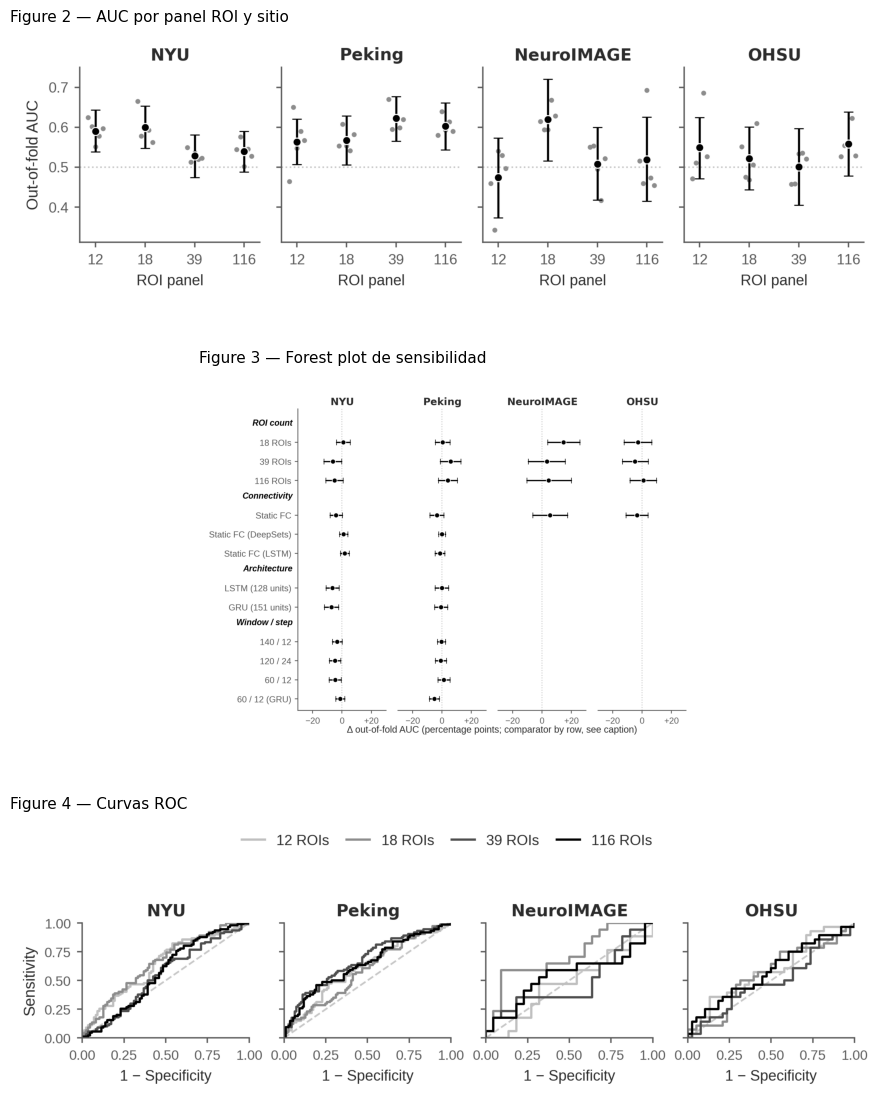

In [3]:
# Galería: las 3 figuras oficiales actuales, una debajo de otra
gallery_files = [
    ("Figure 2 — AUC por panel ROI y sitio", FIGURES_DIR / "figure2_auc_by_roi_restyled.png"),
    ("Figure 3 — Forest plot de sensibilidad", FIGURES_DIR / "figure3_sensitivity_restyled.png"),
    ("Figure 4 — Curvas ROC", FIGURES_DIR / "figure4_roc_restyled.png"),
]

fig, axes = plt.subplots(len(gallery_files), 1, figsize=(9, 12))
for ax, (title, path) in zip(axes, gallery_files):
    if path.exists():
        img = plt.imread(path)
        ax.imshow(img)
        ax.set_title(title, fontsize=11, loc="left")
    else:
        ax.text(0.5, 0.5, f"No encontrado:\n{path}", ha="center", va="center")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Estilo compartido — editar aquí para cambiar el aspecto de las tres figuras

Estos son los mismos parámetros que usa el script de producción
(`figure_style_r2/scripts/build_restyled_figures.py`). Cambia un valor, vuelve a ejecutar esta celda y
luego la celda de la figura que quieras revisar (más abajo) para ver el resultado.


In [4]:
# --- Paleta y tipografía compartidas (edítalas aquí) ---
SITE_ORDER = ["NYU", "Peking", "NeuroIMAGE", "OHSU"]
ROI_ORDER = [12, 18, 39, 116]

_PREFERRED_SANS = ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"]
_available = {f.name for f in fm.fontManager.ttflist}
FONT_FAMILY = next((f for f in _PREFERRED_SANS if f in _available), "DejaVu Sans")

COLOR_POINT = "#000000"        # punto/media (Figura 2 y 3)
COLOR_INDIV = "#8C8C8C"        # puntos individuales por repetición (Figura 2)
COLOR_TEXT = "#2B2B2B"         # texto general
COLOR_AXES = "#595959"         # ejes y ticks
COLOR_REF_LINE = "#C7C7C7"     # línea de referencia (AUC=0.5, Δ=0, diagonal ROC)
COLOR_GROUP_HEADER = "#000000" # encabezados de grupo en Figura 3

# Paleta secuencial gris -> negro para las 4 curvas ROC de Figura 4 (12 a 116 ROIs)
ROC_PALETTE = {12: "#BFBFBF", 18: "#8C8C8C", 39: "#4D4D4D", 116: "#000000"}

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": 8.5,
    "axes.edgecolor": COLOR_AXES,
    "axes.labelcolor": COLOR_TEXT,
    "text.color": COLOR_TEXT,
    "xtick.color": COLOR_AXES,
    "ytick.color": COLOR_AXES,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

def _style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=3, width=0.8)

print("Fuente activa:", FONT_FAMILY)


Fuente activa: Liberation Sans


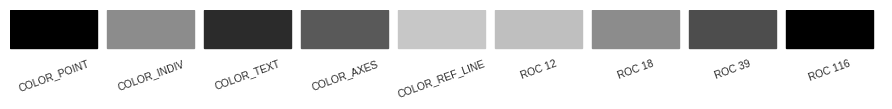

In [5]:
# Vista previa rápida de la paleta activa (para calibrar contraste antes de regenerar las figuras)
swatches = [
    ("COLOR_POINT", COLOR_POINT), ("COLOR_INDIV", COLOR_INDIV), ("COLOR_TEXT", COLOR_TEXT),
    ("COLOR_AXES", COLOR_AXES), ("COLOR_REF_LINE", COLOR_REF_LINE),
    ("ROC 12", ROC_PALETTE[12]), ("ROC 18", ROC_PALETTE[18]), ("ROC 39", ROC_PALETTE[39]), ("ROC 116", ROC_PALETTE[116]),
]
fig, ax = plt.subplots(figsize=(9, 1.1))
for i, (name, color) in enumerate(swatches):
    ax.add_patch(plt.Rectangle((i, 0), 0.9, 1, color=color))
    ax.text(i + 0.45, -0.25, name, ha="center", va="top", fontsize=7.5, rotation=20)
ax.set_xlim(0, len(swatches))
ax.set_ylim(-0.6, 1)
ax.axis("off")
plt.tight_layout()
plt.show()


---
## Figure 2 — Mean out-of-fold AUC by ROI count and site

**Datos (congelados, sin recalcular):** `metrics_by_repeat.csv` (puntos grises individuales por
repetición) y `descriptive_performance.csv` (punto negro = media de las 5 repeticiones, con IC bootstrap
bilateral). Estos son exactamente los mismos números que Table 4 del manuscrito.


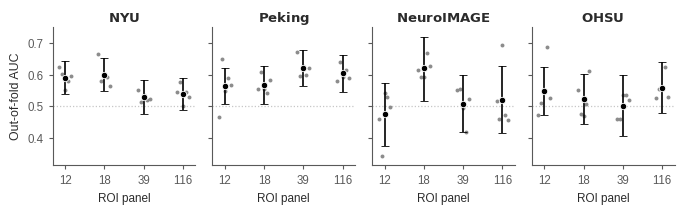

In [6]:
def build_figure2(show=True):
    metrics_by_repeat = pd.read_csv(ROI_OUT / "data" / "metrics_by_repeat.csv")
    desc = pd.read_csv(ROI_OUT / "tables" / "descriptive_performance.csv")

    all_lows = desc["auc_bilateral_ci_low"].tolist()
    all_highs = desc["auc_bilateral_ci_high"].tolist()
    all_reps = metrics_by_repeat["auc"].tolist()
    margin = 0.03
    y_min = max(0.0, min(all_lows + all_reps) - margin)
    y_max = min(1.0, max(all_highs + all_reps) + margin)

    fig, axes = plt.subplots(1, 4, figsize=(6.9, 2.2), sharey=True)
    jitter = np.linspace(-0.15, 0.15, 5)
    x = np.arange(len(ROI_ORDER))

    for ax, site in zip(axes, SITE_ORDER):
        means, los, his = [], [], []
        for roi in ROI_ORDER:
            row = desc[(desc["site"] == site) & (desc["roi_set"] == roi)].iloc[0]
            means.append(row["mean_auc"]); los.append(row["auc_bilateral_ci_low"]); his.append(row["auc_bilateral_ci_high"])
        means_arr, los_arr, his_arr = np.array(means), np.array(los), np.array(his)
        yerr_low = np.clip(means_arr - los_arr, 0, None)
        yerr_high = np.clip(his_arr - means_arr, 0, None)
        ax.errorbar(x, means, yerr=[yerr_low, yerr_high], fmt="o", color=COLOR_POINT, ecolor=COLOR_POINT,
                     markersize=4.6, elinewidth=1.2, capsize=2.7, capthick=1.2, zorder=3,
                     markeredgecolor="white", markeredgewidth=0.6)
        for i, roi in enumerate(ROI_ORDER):
            sub = metrics_by_repeat[(metrics_by_repeat["site"] == site) & (metrics_by_repeat["roi_set"] == roi)]
            reps = sub.sort_values("repeat")["auc"].to_numpy()
            assert len(reps) == 5, (site, roi, len(reps))
            ax.scatter(np.full(5, x[i]) + jitter, reps, color=COLOR_INDIV, s=8, zorder=2, linewidths=0)
        ax.axhline(0.5, color=COLOR_REF_LINE, linestyle=(0, (1, 1.6)), linewidth=0.9, zorder=1)
        ax.set_xticks(x); ax.set_xticklabels([str(r) for r in ROI_ORDER], fontsize=8.3)
        ax.set_title(r"$\mathbf{" + site.replace(" ", r"\ ") + "}$", fontsize=9.5, pad=4, color=COLOR_TEXT)
        ax.set_xlabel("ROI panel", fontsize=8.5)
        ax.set_ylim(y_min, y_max)
        _style_axes(ax)
        ax.tick_params(axis="y", labelsize=8.3)

    axes[0].set_ylabel("Out-of-fold AUC", fontsize=8.9)
    fig.tight_layout(rect=(0, 0, 1, 1))
    fig.subplots_adjust(wspace=0.12)

    # QA: el punto negro + IC debe coincidir exactamente con descriptive_performance.csv (Table 4)
    for site in SITE_ORDER:
        for roi in ROI_ORDER:
            row = desc[(desc["site"] == site) & (desc["roi_set"] == roi)].iloc[0]
            reps = metrics_by_repeat[(metrics_by_repeat["site"] == site) & (metrics_by_repeat["roi_set"] == roi)]["auc"]
            assert abs(reps.mean() - row["mean_auc"]) < 1e-9, (site, roi, reps.mean(), row["mean_auc"])

    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig

fig2 = build_figure2()


---
## Figure 3 — Sensitivity forest plot

**Datos (congelados, sin recalcular):** `figure4_v6_audit.csv` (punto e IC ya calculados, filas con
`status == "evaluated"`), la misma tabla que ya está detrás de la figura oficial. Estos valores son
idénticos a Table 5.


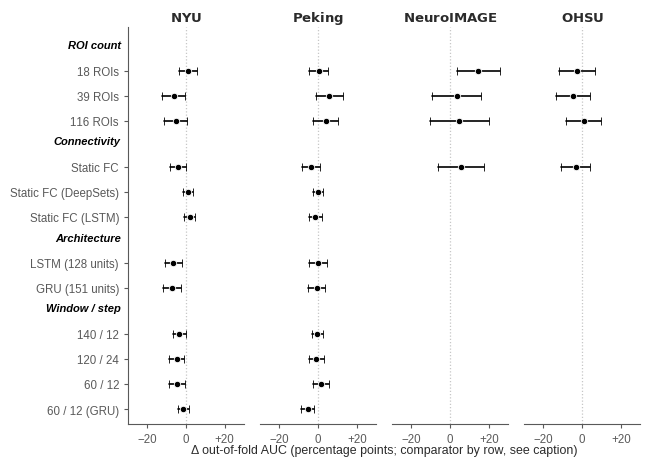

In [7]:
FIGURE_LABELS = {
    "12 ROIs": "12 ROIs", "18 ROIs": "18 ROIs", "39 ROIs": "39 ROIs", "116 ROIs": "116 ROIs",
    "Static connectivity": "Static FC",
    "Static connectivity (DeepSets)": "Static FC (DeepSets)",
    "Static connectivity (LSTM)": "Static FC (LSTM)",
    "LSTM-128": "LSTM (128 units)", "GRU-151": "GRU (151 units)",
    "Window 140 s / step 12 s": "140 / 12", "Window 120 s / step 24 s": "120 / 24",
    "Window 60 s / step 12 s (BrainNetCNN)": "60 / 12", "Window 60 s / step 12 s (GRU)": "60 / 12 (GRU)",
    "ROI panel": "ROI count", "Signal representation": "Connectivity",
    "Model architecture": "Architecture", "Windowing": "Window / step",
}
def disp(label):
    return FIGURE_LABELS.get(label, label)

PANEL_A_GROUPS = [
    ("ROI panel", ["18 ROIs", "39 ROIs", "116 ROIs"]),
    ("Signal representation", ["Static connectivity", "Static connectivity (DeepSets)", "Static connectivity (LSTM)"]),
    ("Model architecture", ["LSTM-128", "GRU-151"]),
    ("Windowing", ["Window 140 s / step 12 s", "Window 120 s / step 24 s",
                   "Window 60 s / step 12 s (BrainNetCNN)", "Window 60 s / step 12 s (GRU)"]),
]
RESTRICTED_TO = {
    "LSTM-128", "GRU-151", "Window 140 s / step 12 s", "Window 120 s / step 24 s",
    "Window 60 s / step 12 s (BrainNetCNN)", "Window 60 s / step 12 s (GRU)",
    "Static connectivity (DeepSets)", "Static connectivity (LSTM)",
}
RESTRICTED_SITES = {"NYU", "Peking"}

def _errorbar(ax, y, est, lo, hi, color=None, markersize=4.6, elinewidth=1.2, capsize=2.7, capthick=1.2):
    color = COLOR_POINT if color is None else color
    xerr_lo = est - lo; xerr_hi = hi - est
    _, caplines, barlinecols = ax.errorbar(
        est, y, xerr=[[xerr_lo], [xerr_hi]], fmt="o", color=color, ecolor=color, elinewidth=elinewidth,
        capsize=capsize, capthick=capthick, markersize=markersize, zorder=3,
        markeredgecolor="white", markeredgewidth=0.6,
    )
    for cap in caplines: cap.set_solid_capstyle("round")
    for coll in barlinecols: coll.set_capstyle("round")

def _y_positions_panel_a():
    ROW_H, HEADER_H, GROUP_GAP = 1.0, 0.62, 0.20
    cursor = 0.0; positions, header_y = {}, {}; first = True
    for group, conds in PANEL_A_GROUPS:
        if not first: cursor -= GROUP_GAP
        first = False
        cursor -= HEADER_H
        header_y[group] = cursor
        for cond in conds:
            cursor -= ROW_H
            positions[cond] = cursor
    offset = -min(list(positions.values()) + list(header_y.values()))
    positions = {k: v + offset for k, v in positions.items()}
    header_y = {k: v + offset for k, v in header_y.items()}
    span = max(list(positions.values()) + list(header_y.values())) + 0.75
    return positions, header_y, span

def build_figure3(show=True):
    audit = pd.read_csv(ROI_OUT / "tables" / "figure4_v6_audit.csv")
    evaluated = audit[audit["status"] == "evaluated"]
    records_a = {(r["site"], r["condition"]): (r["point"], r["ci_low"], r["ci_high"]) for _, r in evaluated.iterrows()}

    all_vals = [v for pair in records_a.values() for v in (pair[1], pair[2])]
    max_abs = max(abs(min(all_vals)), abs(max(all_vals)))
    pad = 0.005
    limit = np.ceil((max_abs + pad) / 0.05) * 0.05
    x_lo, x_hi = -limit, limit
    xticks = [t for t in [-0.20, 0.0, 0.20] if x_lo < t < x_hi] or [round(-limit / 2, 2), 0.0, round(limit / 2, 2)]

    pos_a, header_y_a, span_a = _y_positions_panel_a()
    row_labels_a = [lab for _, labs in PANEL_A_GROUPS for lab in labs]

    V5_SPAN, V5_HEIGHT = 10.83, 3.6
    fig_height = V5_HEIGHT * (span_a / V5_SPAN)

    fig = plt.figure(figsize=(6.5, fig_height))
    gs = fig.add_gridspec(nrows=1, ncols=5, width_ratios=[0.82, 1, 1, 1, 1], wspace=0.14,
                           left=0.03, right=0.99, top=1 - (0.14 * 3.6 / fig_height), bottom=0.16 * 3.6 / fig_height)
    axes = [fig.add_subplot(gs[0, c]) for c in (1, 2, 3, 4)]

    n_drawn = 0
    for ax, site in zip(axes, SITE_ORDER):
        ax.axvline(0.0, color=COLOR_REF_LINE, linestyle=(0, (1, 1.6)), linewidth=0.9, zorder=1)
        for label in row_labels_a:
            y = pos_a[label]; key = (site, label)
            not_evaluated = (label in RESTRICTED_TO) and (site not in RESTRICTED_SITES)
            if not_evaluated or key not in records_a:
                continue
            est, lo, hi = records_a[key]
            _errorbar(ax, y, est, lo, hi)
            n_drawn += 1
        ax.set_title(r"$\mathbf{" + site.replace(" ", r"\ ") + "}$", fontsize=9.5, pad=4, color=COLOR_TEXT)
        ax.set_xlim(x_lo, x_hi); ax.set_xticks(xticks)
        ax.set_xticklabels(["0" if abs(t) < 1e-12 else f"{'−' if t < 0 else '+'}{abs(t) * 100:.0f}" for t in xticks])
        ax.set_ylim(-0.6, span_a)
        _style_axes(ax)
        ax.set_yticks([pos_a[lab] for lab in row_labels_a])
        ax.tick_params(axis="x", labelsize=8.3); ax.tick_params(axis="y", pad=3.2)
        if ax is axes[0]:
            ax.set_yticklabels([disp(lab) for lab in row_labels_a], fontsize=8.3)
        else:
            ax.set_yticklabels([]); ax.spines["left"].set_visible(False); ax.tick_params(left=False)

    for group_label, y in header_y_a.items():
        axes[0].text(-0.06, y, disp(group_label), fontsize=8.0, style="italic", fontweight="semibold",
                     color=COLOR_GROUP_HEADER, ha="right", va="center",
                     transform=axes[0].get_yaxis_transform(), clip_on=False)

    center_x = (axes[0].get_position().x0 + axes[3].get_position().x1) / 2
    bottom_of_axes = min(ax.get_position().y0 for ax in axes)
    fig.text(center_x, max(0.01, bottom_of_axes - 0.055 * 3.6 / fig_height),
              "Δ out-of-fold AUC (percentage points; comparator by row, see caption)", fontsize=8.9, ha="center", va="top")

    assert n_drawn == len(evaluated) == 32, f"expected 32 drawn points, drew {n_drawn}"
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig

fig3 = build_figure3()


---
## Figure 4 — ROC curves

**Datos (congelados, sin recalcular):** `predictions_val.csv` por sitio/panel ROI, ya generados por las
corridas oficiales de BrainNetCNN (`results/runs/...`). El AUC recomputado aquí es únicamente una
comprobación de QA contra `descriptive_performance.csv` (Table 4); pequeñas diferencias son esperadas
porque el método de agregación es distinto (media de probabilidades vs. media de 5 AUCs por repetición),
y ya estaban presentes en la figura oficial.


/sessions/laughing-wizardly-archimedes/tmp/ipykernel_8/2745096101.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tpr[order], fpr[order]))
/sessions/laughing-wizardly-archimedes/tmp/ipykernel_8/2745096101.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tpr[order], fpr[order]))
/sessions/laughing-wizardly-archimedes/tmp/ipykernel_8/2745096101.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tpr[order], fpr[order]))
/sessions/laughing-wizardly-archimedes/tmp/ipykernel_8/2745096101.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np

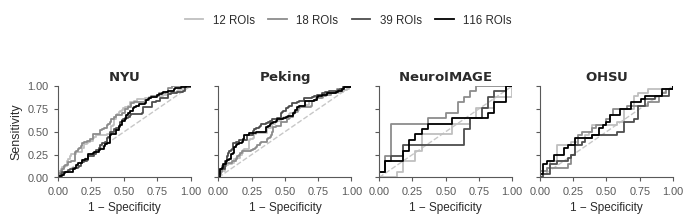

Máxima diferencia absoluta entre AUC recomputado (QA) y Table 4: 0.0995


,site,roi_set,n_participants,recomputed_auc_mean_prob_method,table4_auc_mean_of_5_reps_method,abs_diff
0,NYU,12,177,0.639719,0.590473,0.049246
1,NYU,18,177,0.652043,0.599974,0.052069
2,NYU,39,177,0.544891,0.528301,0.016590
3,NYU,116,177,0.566922,0.539310,0.027612
4,Peking,12,183,0.608480,0.563749,0.044731
5,Peking,18,183,0.582507,0.567518,0.014989
6,Peking,39,183,0.675614,0.622217,0.053397
7,Peking,116,183,0.641086,0.603298,0.037788
8,NeuroIMAGE,12,39,0.475936,0.473797,0.002139
9,NeuroIMAGE,18,39,0.719251,0.619786,0.099465


In [8]:
RUN_DIRS = {
    (12, "NYU"): "NYU_rois12_w60s6_brainnetcnn_control_baseline_v13_3e220e5c",
    (12, "Peking"): "Peking_rois12_w60s6_brainnetcnn_control_baseline_v13_bc841110",
    (12, "NeuroIMAGE"): "NeuroIMAGE_rois12_w61s6_brainnetcnn_control_baseline_v13_2b729a8c",
    (12, "OHSU"): "OHSU_rois12_w48s5_brainnetcnn_control_baseline_v13_1a7c37ce",
    (18, "NYU"): "NYU_rois18_w60s6_brainnetcnn_control_baseline_v13_662d71a9",
    (18, "Peking"): "Peking_rois18_w60s6_brainnetcnn_control_baseline_v13_0bf7fa0e",
    (18, "NeuroIMAGE"): "NeuroIMAGE_rois18_w61s6_brainnetcnn_control_baseline_v13_93342cf0",
    (18, "OHSU"): "OHSU_rois18_w48s5_brainnetcnn_2ce6c48e",
    (39, "NYU"): "NYU_rois39_w60s6_brainnetcnn_control_base_line_1521c348",
    (39, "Peking"): "Peking_rois39_w60s6_brainnetcnn_control_baseline_v13_396e34d2",
    (39, "NeuroIMAGE"): "NeuroIMAGE_rois39_w61s6_brainnetcnn_control_baseline_v13_dc028168",
    (39, "OHSU"): "OHSU_rois39_w48s5_brainnetcnn_control_baseline_v13_299719fe",
    (116, "NYU"): "NYU_rois116_w60s6_brainnetcnn_control_baseline_v13_160b89cd",
    (116, "Peking"): "Peking_rois116_w60s6_brainnetcnn_240732d1",
    (116, "NeuroIMAGE"): "NeuroIMAGE_rois116_w61s6_brainnetcnn_control_baseline_v13_669d72bd",
    (116, "OHSU"): "OHSU_rois116_w48s5_brainnetcnn_control_baseline_v13_f82f17b4",
}

def _roc_points(y_true, y_score):
    order = np.argsort(-y_score, kind="mergesort")
    y_true = y_true[order]
    tps = np.cumsum(y_true); fps = np.cumsum(1 - y_true)
    n_pos, n_neg = y_true.sum(), len(y_true) - y_true.sum()
    tpr = np.concatenate([[0.0], tps / n_pos, [1.0]])
    fpr = np.concatenate([[0.0], fps / n_neg, [1.0]])
    return fpr, tpr

def _auc_trapz(fpr, tpr):
    order = np.argsort(fpr)
    return float(np.trapz(tpr[order], fpr[order]))

def build_figure4(show=True):
    desc = pd.read_csv(ROI_OUT / "tables" / "descriptive_performance.csv")
    fig, axes = plt.subplots(1, 4, figsize=(6.9, 1.9), sharey=True)
    qa_rows = []

    for ax, site in zip(axes, SITE_ORDER):
        for roi in ROI_ORDER:
            run_dir = RUN_DIRS[(roi, site)]
            path = RUNS_ROOT / str(roi) / run_dir / "predictions_val.csv"
            assert path.exists(), f"missing predictions file: {path}"
            df = pd.read_csv(path)
            per_subj = df.groupby("subject_id").agg(y_true=("y_true", "first"), y_prob=("y_prob", "mean"))
            y_true = per_subj["y_true"].to_numpy(); y_prob = per_subj["y_prob"].to_numpy()
            fpr, tpr = _roc_points(y_true, y_prob)
            recomputed_auc = _auc_trapz(fpr, tpr)
            table4_auc = desc[(desc["site"] == site) & (desc["roi_set"] == roi)]["mean_auc"].iloc[0]
            qa_rows.append({"site": site, "roi_set": roi, "n_participants": len(per_subj),
                             "recomputed_auc_mean_prob_method": recomputed_auc,
                             "table4_auc_mean_of_5_reps_method": table4_auc,
                             "abs_diff": abs(recomputed_auc - table4_auc)})
            ax.step(fpr, tpr, where="post", color=ROC_PALETTE[roi], linewidth=1.3, label=f"{roi} ROIs")
        ax.plot([0, 1], [0, 1], color=COLOR_REF_LINE, linestyle="--", linewidth=1.0, zorder=1)
        ax.set_title(r"$\mathbf{" + site.replace(" ", r"\ ") + "}$", fontsize=9.5, pad=4, color=COLOR_TEXT)
        ax.set_xlabel("1 − Specificity", fontsize=8.5)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        _style_axes(ax); ax.tick_params(labelsize=7.8)

    axes[0].set_ylabel("Sensitivity", fontsize=8.9)
    handles, labels = axes[0].get_legend_handles_labels()
    legend = fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, 1.0),
                         frameon=False, fontsize=8.3, handlelength=1.6, columnspacing=1.2)
    fig.tight_layout(rect=(0, 0, 1, 0.90))

    qa = pd.DataFrame(qa_rows)
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, qa

fig4, qa4 = build_figure4()
qa_max_diff = qa4["abs_diff"].max()
print(f"Máxima diferencia absoluta entre AUC recomputado (QA) y Table 4: {qa_max_diff:.4f}")
qa4


---
## Guardar cambios (opcional, apagado por defecto)

Si el equipo decide adoptar un cambio de estilo hecho arriba, esta celda sobrescribe los PNG/SVG que
usa el manuscrito en `figure_style_r2/figures/`. **No se ejecuta nada por defecto**: cambia
`SAVE_TO_DISK = True` y vuelve a ejecutar esta celda solo cuando quieras confirmar el guardado.

Después de guardar, hay que volver a insertar la imagen en el `.docx` siguiendo el mismo procedimiento
usado en las fases anteriores (reemplazo de `word/media/imageN.png`, verificación de hash y render
completo antes de reemplazar el archivo oficial).


In [9]:
SAVE_TO_DISK = False  # cambia a True para sobrescribir los PNG/SVG oficiales

if SAVE_TO_DISK:
    fig2 = build_figure2(show=False)
    fig2.savefig(FIGURES_DIR / "figure2_auc_by_roi_restyled.png", dpi=320)
    fig2.savefig(FIGURES_DIR / "figure2_auc_by_roi_restyled.svg")

    fig3 = build_figure3(show=False)
    fig3.savefig(FIGURES_DIR / "figure3_sensitivity_restyled.png", dpi=320, pad_inches=0.03)
    fig3.savefig(FIGURES_DIR / "figure3_sensitivity_restyled.svg", pad_inches=0.03)

    fig4, _ = build_figure4(show=False)
    fig4.savefig(FIGURES_DIR / "figure4_roc_restyled.png", dpi=320, bbox_inches="tight")
    fig4.savefig(FIGURES_DIR / "figure4_roc_restyled.svg", bbox_inches="tight")

    print("Guardado en:", FIGURES_DIR)
else:
    print("SAVE_TO_DISK está en False: no se sobrescribió ningún archivo.")


SAVE_TO_DISK está en False: no se sobrescribió ningún archivo.
